# Análisis Exploratorio de Datos (EDA)

**TFM:** Sistema de Apoyo a la Decisión Clínica en Oncología Pediátrica  
**Autor:** Alonso Castañón González  
**Dataset:** SEER Research Data — Osteosarcoma y Sarcoma de Ewing pediátrico (2000–2023)

**Objetivo de este notebook:** Explorar el dataset limpio generado en `01_limpieza.ipynb`
para comprender la distribución de las variables, su relación con la variable objetivo
(supervivencia a 5 años) y detectar patrones que orienten las decisiones de modelado en
`03_modelo_ML.ipynb`.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

SEED = 2026
np.random.seed(SEED)

print("Entorno configurado correctamente")

Entorno configurado correctamente


## 1) Carga del dataset limpio y verificación

Se carga el dataset `seer_osteosarcoma_ewing_clean.csv`, generado como salida final de `01_limpieza.ipynb`. Este notebook parte siempre de dicho archivo para garantizar que la limpieza se ejecuta una única vez y que todos los notebooks posteriores trabajan sobre exactamente la misma versión del dataset.

Antes de cualquier análisis se realiza una verificación para confirmar que el dataset cargado corresponde al resultado documentado en el notebook de limpieza.

In [2]:
# Carga del dataset limpio
DATA_PATH = '../data/seer_osteosarcoma_ewing_clean.parquet'
df = pd.read_parquet(DATA_PATH)

print(f"Shape: {df.shape}")

# Verificación de tipos de datos
print("\n---- TIPOS DE DATOS ----")
print(df.dtypes)

# Comprobación de ausencia de valores Blank(s)
n_blanks = (df.astype(str) == 'Blank(s)').sum().sum()
print(f"Valores 'Blank(s)' en el dataset: {n_blanks}")

# Comprobación de los valores NaN por columna
print("\n---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----")
missing_pct = (df.isnull().mean() * 100).round(1)
print(missing_pct[missing_pct > 0])

df.head(5)

Shape: (4915, 15)

---- TIPOS DE DATOS ----
age_group               category
sex                     category
year_diagnosis             int64
tumor_type              category
primary_site            category
stage                   category
tumor_size_cs            float64
surgery_code            category
radiation               category
chemotherapy            category
survival_months            int64
survival_months_flag    category
cause_specific_death    category
vital_status            category
target                     int64
dtype: object
Valores 'Blank(s)' en el dataset: 0

---- PORCENTAJE DE VALORES MISSING POR COLUMNA ----
stage            19.2
tumor_size_cs    61.1
surgery_code      4.3
dtype: float64


,age_group,sex,year_diagnosis,tumor_type,primary_site,stage,tumor_size_cs,surgery_code,radiation,chemotherapy,survival_months,survival_months_flag,cause_specific_death,vital_status,target
0,05-09 years,Female,2004,Ewing sarcoma,Upper limb bones,Regional by direct extension only,64.0,Partial resection,Radiation,Yes,239,complete,Alive / Other cause,Alive,0
1,15-19 years,Male,2001,Ewing sarcoma,Trunk / ribs / sternum,NaN,NaN,Radical resection,No radiation,Yes,275,complete,Alive / Other cause,Alive,0
2,10-14 years,Female,2001,Ewing sarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,119,complete,Dead (cancer),Dead,0
3,10-14 years,Female,2001,Osteosarcoma NOS,Lower limb bones,NaN,NaN,Radical resection,No radiation,Yes,274,complete,Alive / Other cause,Alive,0
4,15-19 years,Female,2000,Chondroblastic osteosarcoma,Pelvis / hip,NaN,NaN,No surgery,Radiation,Yes,23,complete,Dead (cancer),Dead,1


### 1.b) Diccionario de variables

También se documenta el significado clínico, tipo y fuente de cada variable del dataset. Este diccionario sirve como referencia a lo largo de todo el proyecto y permite trazar cada columna hasta su variable original de SEER, dado que varias columnas fueron renombradas y recodificadas en el notebook de limpieza `01_limpieza.ipynb`.

| Variable | Tipo | Significado clínico | Unidad / Categorías | Fuente SEER | % Missing |
|---|---|---|---|---|---|
| `age_group` | categórica ordinal | Grupo de edad al diagnóstico | 00 years, 01-04, 05-09, 10-14, 15-19 | Age recode with <1 year olds and 90+ | 0.0% |
| `sex` | categórica nominal | Sexo del paciente | Female / Male | Sex | 0.0% |
| `year_diagnosis` | numérica discreta | Año de diagnóstico | 2000–2023 | Year of diagnosis | 0.0% |
| `tumor_type` | categórica nominal | Subtipo histológico (ICD-O-3 agrupado) | 9 subtipos (Ewing sarcoma, Osteosarcoma NOS, ...) | Histologic Type ICD-O-3 | 0.0% |
| `primary_site` | categórica nominal | Localización anatómica del tumor primario (agrupada) | 8 grupos (Lower limb bones, Pelvis/hip, ...) | Primary Site | 0.0% |
| `stage` | categórica ordinal | Estadio combinado de extensión tumoral | 5 niveles (Localized only → Distant site(s)/node(s) involved) | Combined Summary Stage (2004+) | 19.2% |
| `tumor_size_cs` | numérica continua | Tamaño del tumor primario | mm (rango real 2–888; solo válido 2004–2015) | CS tumor size (2004-2015) | 61.1% |
| `surgery_code` | categórica nominal | Tipo de cirugía sobre el tumor primario | 4 grupos (No surgery, Partial/Radical resection, NOS/Unknown) | RX Summ--Surg Prim Site (1998-2022) | 4.3% |
| `radiation` | categórica nominal | Administración de radioterapia | 4 grupos (No radiation, Radiation, Recommended/Unknown, Refused) | Radiation recode | 0.0% |
| `chemotherapy` | categórica nominal | Administración de quimioterapia | Yes / No-Unknown | Chemotherapy recode (yes, no/unk) | 0.0% |
| `survival_months` | numérica discreta | Meses de seguimiento desde el diagnóstico | 0–287 meses | Survival months | 0.0% |
| `survival_months_flag` | categórica nominal | Indicador de completitud del dato de seguimiento | complete, complete_zero, incomplete, incomplete_zero | Survival months flag | 0.0% |
| `cause_specific_death` | categórica nominal | Causa de fallecimiento (si aplica) | Alive/Other cause, Dead (cancer), Dead (unknown cause) | SEER cause-specific death classification | 0.0% |
| `vital_status` | categórica nominal | Estado vital al cierre del estudio | Alive / Dead | Vital status recode (study cutoff used) | 0.0% |
| `target` | binaria (0/1) | No supervivencia a 5 años (60 meses) | 0 = sobrevive, 1 = no sobrevive | Derivada de `vital_status` + `survival_months` | 0.0% |

**Nota sobre leakage:** `cause_specific_death`, `vital_status`, `survival_months` y `survival_months_flag`
se usan en el EDA para construir un mejor análisis de supervivencia, pero quedarán excluidas del conjunto que se utilice para los modelos en `03_modelo_ML.ipynb`, al ser variables de seguimiento posteriores al diagnóstico.

## 2) Estadística descriptiva general

Se obtiene una visión general del dataset mediante estadísticos descriptivos: resumen numérico para las variables continuas/discretas, y frecuencias para las variables categóricas. Esto permite detectar rangos, escalas y posibles anomalías.

Además se definen aquí las listas de variables numéricas y categóricas del dataset, que se reutilizarán a lo largo de todo el notebook, evitando redefinirlas en cada sección y separando también en una variable independiente aquellas que producen *data leakage*, con el objetivo de evitar futuros errores.

In [3]:
# Variables numéricas y categóricas del dataset
num_vars = ['year_diagnosis', 'tumor_size_cs', 'survival_months']
cat_vars = ['age_group', 'sex', 'tumor_type', 'primary_site', 'stage', 'surgery_code', 'radiation', 'chemotherapy']
leakage_vars = ['survival_months_flag', 'cause_specific_death', 'vital_status']
target_var = 'target'

In [4]:
# Estadística descriptiva de variables numéricas
df[num_vars].describe().round(2)

,year_diagnosis,tumor_size_cs,survival_months
count,4915.00,1910.00,4915.00
mean,2011.69,98.80,96.05
std,6.88,66.05,83.39
min,2000.00,2.00,0.00
25%,2006.00,60.00,24.00
50%,2012.00,88.00,67.00
75%,2018.00,125.00,159.00
max,2023.00,888.00,287.00


In [5]:
# Estadística descriptiva de variables categóricas (incluye leakage_vars para contexto)
df[cat_vars + leakage_vars].describe()

,age_group,sex,tumor_type,primary_site,stage,surgery_code,radiation,chemotherapy,survival_months_flag,cause_specific_death,vital_status
count,4915,4915,4915,4915,3973,4705,4915,4915,4915,4915,4915
unique,5,2,9,8,5,4,4,2,4,3,2
top,15-19 years,Male,Ewing sarcoma,Lower limb bones,Localized only,Radical resection,No radiation,Yes,complete,Alive / Other cause,Alive
freq,1925,2846,2128,2712,1384,2934,3684,4658,4721,3376,3228


### Gráficos descriptivos combinados

Se exploran combinaciones entre variables descriptivas para detectar patrones estructurales
en la muestra, sin utilizar todavía con la variable objetivo.

#### Distribución de edad por sexo

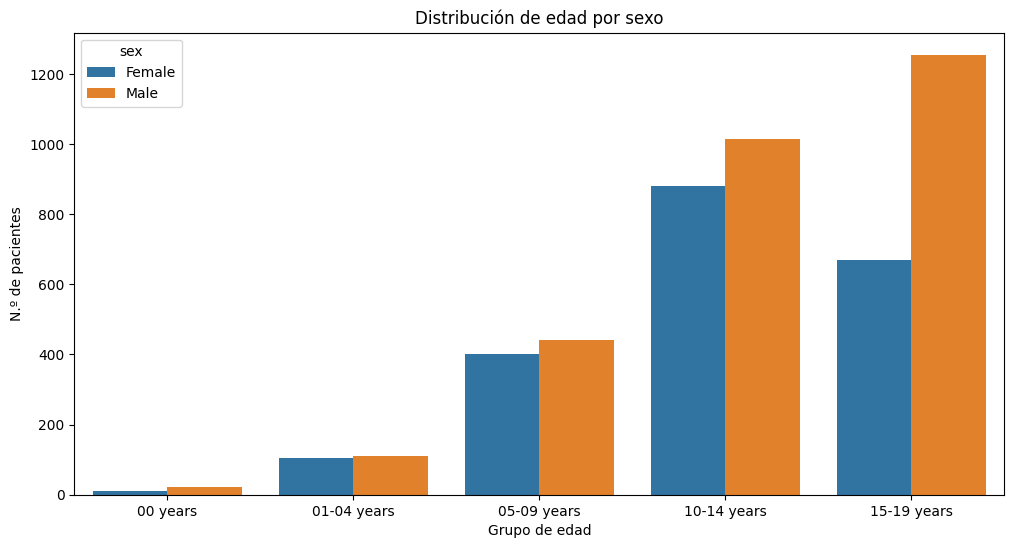

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x='age_group', hue='sex', ax=ax)
ax.set_title('Distribución de edad por sexo')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('N.º de pacientes')
plt.show()

#### Combinación de tratamientos: cirugía y radioterapia

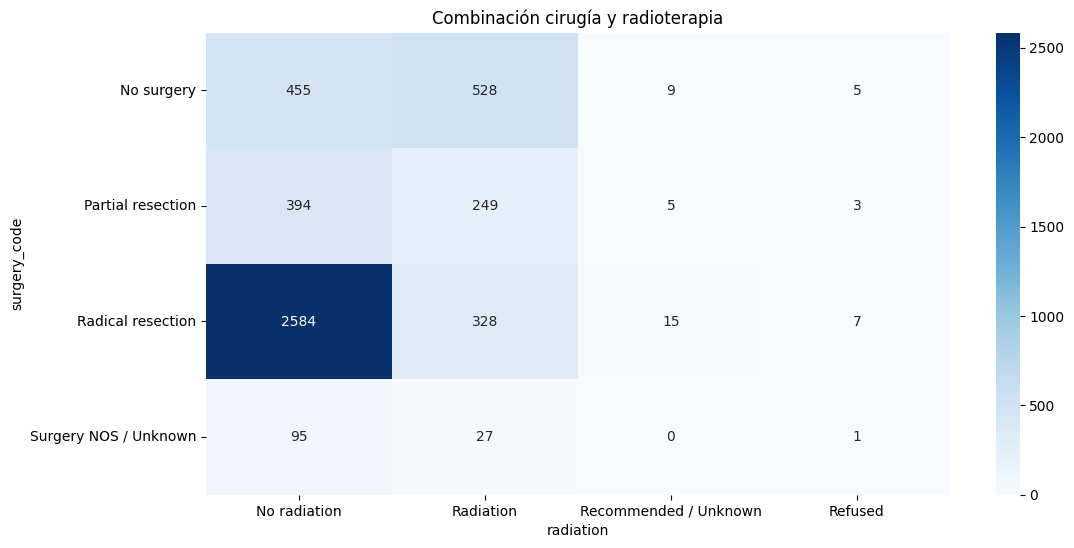

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ct_treat = pd.crosstab(df['surgery_code'], df['radiation'])
sns.heatmap(ct_treat, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Combinación cirugía y radioterapia')
plt.show()

El heatmap anterior está dominado visualmente por *Radical resection + No radiation*, lo que oculta la distribución relativa dentro de cada tipo de cirugía. Se normaliza por fila (% dentro de cada categoría de `surgery_code`) y se añade `chemotherapy` como panel adicional, ya que al tener solo 2 categorías muy desbalanceadas no aportaba valor combinarla en un único heatmap de 3 dimensiones.

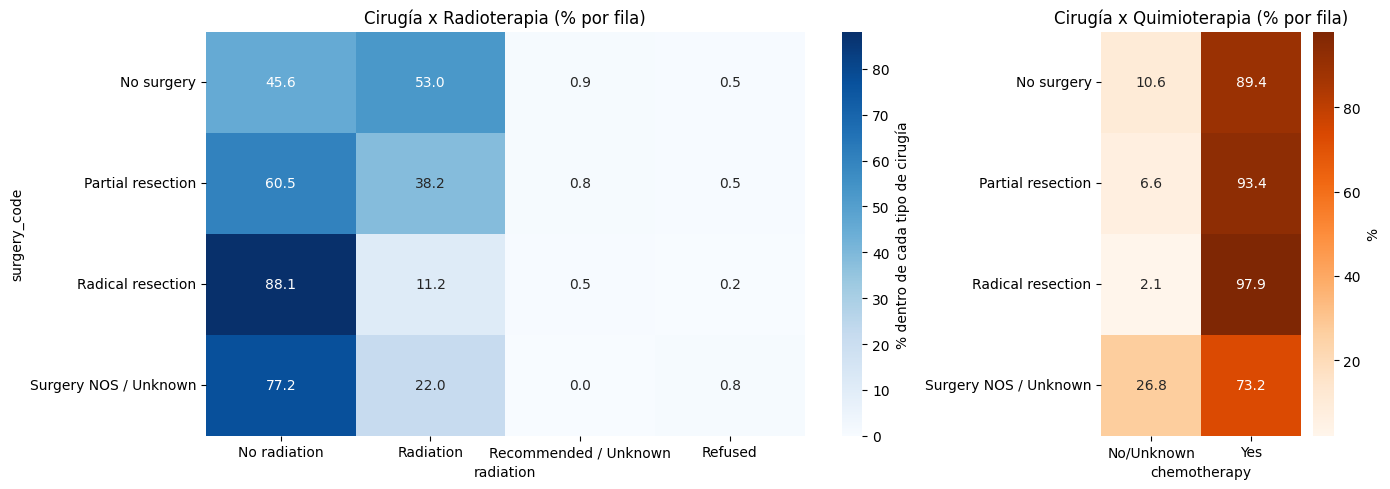

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})

# Panel 1: cirugía x radioterapia, normalizado por fila
ct_radiation = pd.crosstab(df['surgery_code'], df['radiation'], normalize='index') * 100
sns.heatmap(ct_radiation, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            cbar_kws={'label': '% dentro de cada tipo de cirugía'})
axes[0].set_title('Cirugía x Radioterapia (% por fila)')

# Panel 2: cirugía x quimioterapia, normalizado por fila
ct_chemo = pd.crosstab(df['surgery_code'], df['chemotherapy'], normalize='index') * 100
sns.heatmap(ct_chemo, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            cbar_kws={'label': '%'})
axes[1].set_title('Cirugía x Quimioterapia (% por fila)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Se observa que, cuando no hay cirugía, la radioterapia se usa como alternativa en el 53% de los casos, frente a solo 11.2% cuando hay resección radical, siendo coherente con que la radioterapia se reserva como tratamiento local cuando la cirugía no es viable. Y en Surgery NOS/Unknown, tanto la tasa de quimioterapia como la de "No/Unknown" sugieren que esa categoría no solo tiene cirugía mal documentada, sino que probablemente coincide con historias clínicas incompletas en general, lo que puede ser un patrón de calidad de dato a tener en cuenta, no solo clínico.

#### Evolución temporal de diagnósticos por tipo de tumor

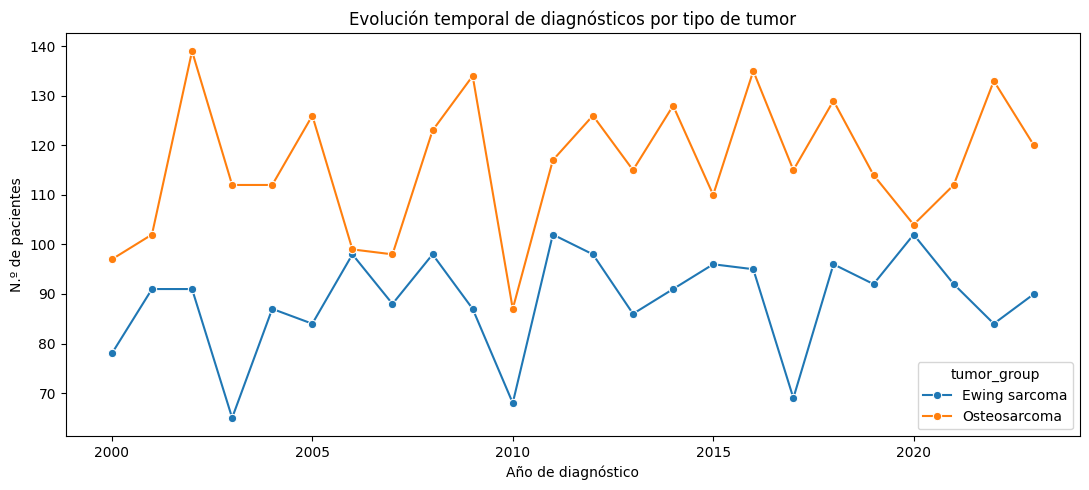

In [9]:
df['tumor_group'] = df['tumor_type'].apply(
    lambda x: 'Ewing sarcoma' if x == 'Ewing sarcoma' else 'Osteosarcoma'
)

temporal = df.groupby(['year_diagnosis', 'tumor_group'], observed=True).size().reset_index(name='n_pacientes')

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=temporal, x='year_diagnosis', y='n_pacientes', hue='tumor_group', marker='o', ax=ax)
ax.set_title('Evolución temporal de diagnósticos por tipo de tumor')
ax.set_xlabel('Año de diagnóstico')
ax.set_ylabel('N.º de pacientes')
plt.tight_layout()
plt.show()

## 3) Distribución de la variable objetivo (target) y desbalanceo

`target` es la variable binaria de no supervivencia a 5 años: 1 si el paciente falleció antes de los 60 meses de seguimiento, 0 si sobrevive o fallece después. Además de comprobar el desbalanceo de esta variable, hay que tener en cuenta cómo funciona el seguimiento de los pacientes. 

Los que siguen vivos cuando termina el estudio de 5 años no sabemos cuándo van a fallecer, solo que, de momento, han sobrevivido más tiempo que el que llevamos observándolos. Esto no es un dato que falte, es un dato que todavía no ha sucedido. En cambio, a los pacientes fallecidos sí les conocemos el momento exacto del evento.

Si tratamos `target` como un simple problema de clasificación desbalanceada sin tener esto en cuenta, podemos tomar decisiones de modelado equivocadas. Por ejemplo, aplicar técnicas para corregir el desbalanceo (como aumentar artificialmente el número de muestras de la clase minoritaria) sin darnos cuenta de que parte de esa "clase mayoritaria" no representa realmente supervivientes confirmados a largo plazo, sino pacientes cuyo desenlace real todavía no conocemos.

In [10]:
# Distribución de la variable objetivo
print("---- DISTRIBUCIÓN DE TARGET ----")
print(df['target'].value_counts())
print((df['target'].value_counts(normalize=True) * 100).round(1))

---- DISTRIBUCIÓN DE TARGET ----
target
0    3520
1    1395
Name: count, dtype: int64
target
0    71.6
1    28.4
Name: proportion, dtype: float64


### Verificación de coherencia entre `target`, `vital_status` y `survival_months`

In [15]:
# Verificación cruzada: todo Dead con target=1 debe tener survival_months < 60
print(pd.crosstab(df['vital_status'], df['target']))

target           0     1
vital_status            
Alive         3228     0
Dead           292  1395


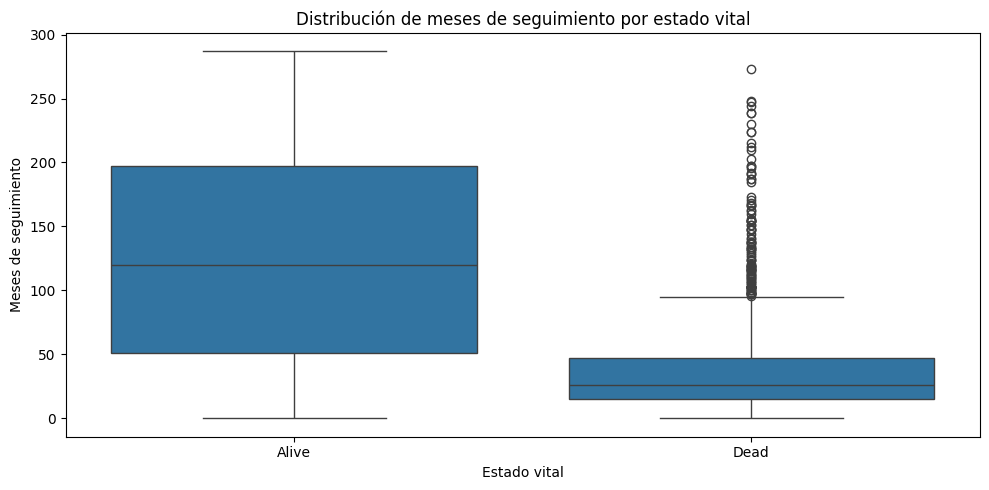

               count   mean   std  min   25%    50%    75%    max
vital_status                                                     
Alive         3228.0  126.7  84.6  0.0  51.0  120.0  197.0  287.0
Dead          1687.0   37.3  36.5  0.0  15.0   26.0   47.0  273.0


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='vital_status', y='survival_months', ax=ax)
ax.set_title('Distribución de meses de seguimiento por estado vital')
ax.set_xlabel('Estado vital')
ax.set_ylabel('Meses de seguimiento')
plt.tight_layout()
plt.show()

print(df.groupby('vital_status', observed=True)['survival_months'].describe().round(1))

Estos datos tambien sirven de ayuda para conocer que los fallecidos tienen una media de 37.3 meses de supervivencia. Es decir, la mayoría de las muertes ocurren dentro de los primeros 2-3 años tras el diagnóstico, muy por debajo del umbral de 5 años (60 meses) que define el target. Esto es coherente con el comportamiento agresivo típico de estos tumores óseos pediátricos: cuando la enfermedad progresa desfavorablemente, suele hacerlo relativamente pronto, mientras que los supervivientes tienden a mantenerse libres de evento a largo plazo (media de seguimiento de 126.7 meses en el grupo `Alive`).

## 4) Análisis univariante

Se analiza la distribución individual de cada variable categórica (frecuencias) y numérica (distribución, rango), tanto para detectar patrones de la muestra como para identificar posibles inconsistencias lógicas antes de pasar al análisis bivariante.

In [17]:
for col in cat_vars:
    print(f"---- {col} ----")
    print(df[col].value_counts(dropna=False))
    print()

---- age_group ----
age_group
15-19 years    1925
10-14 years    1896
05-09 years     843
01-04 years     217
00 years         34
Name: count, dtype: int64

---- sex ----
sex
Male      2846
Female    2069
Name: count, dtype: int64

---- tumor_type ----
tumor_type
Ewing sarcoma                                    2128
Osteosarcoma NOS                                 2058
Chondroblastic osteosarcoma                       410
Telangiectatic osteosarcoma                       108
Central osteosarcoma                              103
Fibroblastic osteosarcoma                          76
Small cell osteosarcoma                            25
Intraosseous well differentiated osteosarcoma       6
Osteosarcoma in Paget disease                       1
Name: count, dtype: int64

---- primary_site ----
primary_site
Lower limb bones          2712
Upper limb bones           621
Pelvis / hip               563
Trunk / ribs / sternum     422
Skull / head / jaw         241
Vertebral column           177
O

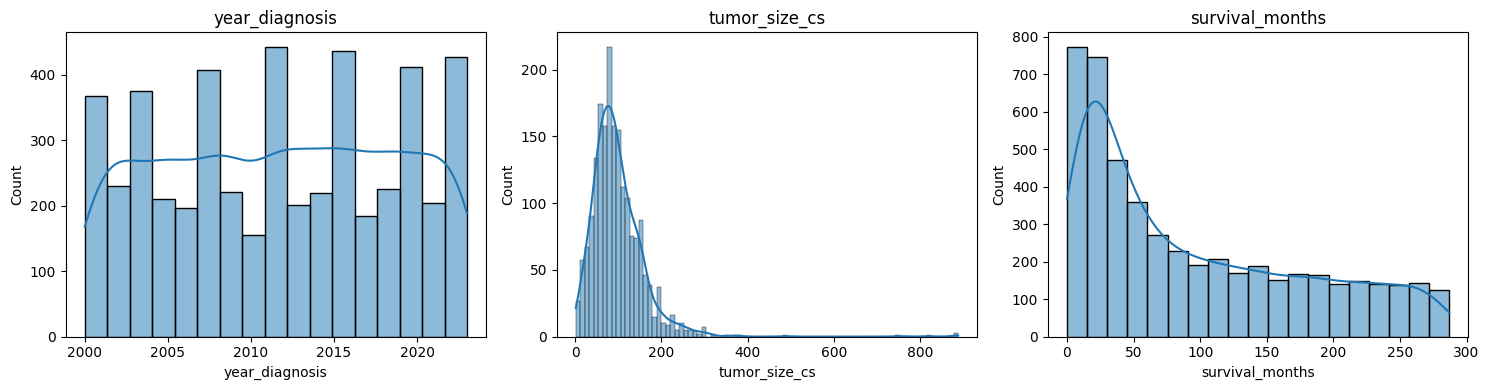

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_vars):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Detección de inconsistencias lógicas

Antes de dar por buena la distribución de cada variable, se revisan combinaciones que podrían señalar errores de registro: valores fuera de rango biológicamente plausible, incoherencias entre variables relacionadas, y filas duplicadas.

In [20]:
print("---- 1) survival_months=0 con vital_status=Alive ----")
print(len(df[(df['survival_months']==0) & (df['vital_status']=='Alive')]))

print("\n---- 2) tumor_size_cs > 500mm (extremo) ----")
extreme = df[df['tumor_size_cs']>500]
print(extreme[['tumor_size_cs','tumor_type','primary_site','age_group']])

print("\n---- 3) tumor_size_cs < 5mm (muy pequeño) ----")
print(df[df['tumor_size_cs']<5][['tumor_size_cs','tumor_type','primary_site']])

print("\n---- 4) Filas duplicadas exactas ----")
print(df.duplicated().sum())

print("\n---- 5) Osteosarcoma en age_group '00 years' (raro clínicamente) ----")
print(df[df['age_group']=='00 years']['tumor_type'].value_counts())

---- 1) survival_months=0 con vital_status=Alive ----
22

---- 2) tumor_size_cs > 500mm (extremo) ----
      tumor_size_cs                   tumor_type            primary_site  \
725           750.0             Osteosarcoma NOS        Lower limb bones   
1783          888.0                Ewing sarcoma  Trunk / ribs / sternum   
4131          820.0  Chondroblastic osteosarcoma        Lower limb bones   
4214          888.0             Osteosarcoma NOS        Lower limb bones   
4668          888.0                Ewing sarcoma        Upper limb bones   

        age_group  
725   10-14 years  
1783  10-14 years  
4131  15-19 years  
4214  15-19 years  
4668  10-14 years  

---- 3) tumor_size_cs < 5mm (muy pequeño) ----
      tumor_size_cs        tumor_type      primary_site
1927            3.0     Ewing sarcoma  Upper limb bones
2733            3.0  Osteosarcoma NOS  Lower limb bones
4250            3.0  Osteosarcoma NOS  Upper limb bones
4272            2.0  Osteosarcoma NOS  Lower lim

**Interpretación:**

- **22 casos vivos con 0 meses de seguimiento**: plausibles — corresponden a diagnósticos muy
  recientes, próximos al corte del estudio (Nov 2025). No es un error, se anota como
  característica esperable del extremo derecho de la ventana temporal.

- **5 casos con tumor_size_cs entre 750-888mm**: valores extremos pero dentro del rango
  técnicamente válido de SEER (no son códigos especiales). Tumores óseos pediátricos muy
  avanzados en pelvis/tronco pueden alcanzar tamaños considerables antes del diagnóstico.
  Se marcan como candidatos a revisión/winsorización en el notebook de modelado, sin
  eliminarlos aquí.

- **4 casos con tumor_size_cs de 2-3mm**: extremadamente pequeños para tumores sintomáticos,
  pero no imposibles (hallazgos incidentales). Se dejan sin modificar.

- **74 filas duplicadas exactas**: dado que el dataset combina variables categóricas con pocas
  categorías (edad en 5 grupos, 8 localizaciones, 4 tipos de cirugía, etc.), la probabilidad de
  que dos pacientes distintos compartan el mismo perfil completo por azar no es desdeñable.
  No se eliminan, ya que no hay identificador de paciente que permita confirmar si son
  duplicados reales o coincidencias — eliminarlas sin evidencia sería un riesgo mayor que
  conservarlas.

- **32 casos de Ewing sarcoma y 2 de osteosarcoma en `age_group = '00 years'`**: el osteosarcoma
  en menores de 1 año es extremadamente infrecuente en la literatura (típicamente asociado a
  picos de crecimiento óseo en adolescencia), mientras que Ewing sarcoma congénito, aunque raro,
  está documentado. Se mantienen ambos subgrupos por ser volumen bajo y no existir evidencia de
  error de registro, pero se señala como limitación a mencionar en la memoria del TFM.